语言模型和数据集

## 1. 什么是语言模型

语言模型的目标是估计一个词序列出现的概率：

P(x₁, x₂, …, x_T)

其中 x_t 表示第 t 个词（或字符）。

本质上，语言模型用于根据前面的词预测下一个词，评估一句话是否“自然”

## 2. 概率分解（核心思想）

根据概率的链式法则：

P(x₁, …, x_T) = ∏ P(x_t | x₁, …, x_{t-1})

一个句子的概率可以分解为一系列“条件概率”的乘积。

例如：
“deep learning is fun”可以表示为：

P(deep)  
× P(learning | deep)  
× P(is | deep, learning)  
× P(fun | deep, learning, is)

## 3. 概率的估计方法

最简单的方法是基于“频率统计”。

单词概率为
P(x) ≈ n(x) / n

其中n(x)是单词 x 出现的次数，n是语料库中总词数  
条件概率为P(x' | x) ≈ n(x, x') / n(x)

例如：
P(learning | deep) =  
n(deep, learning) / n(deep)

## 4. 数据稀疏问题

很多词组合在数据中没有出现，这时概率会变成0。

## 5. 拉普拉斯平滑（解决方法）

通过给所有计数加一个小值，避免概率为 0：

P(x) = (n(x) + ε) / (n + ε)

P(x' | x) = (n(x, x') + ε) / (n(x) + ε)

## 6. 统计语言模型的缺点

1. 需要存储大量计数（内存大）
2. 无法理解语义（如 cat 和 feline）
3. 长序列几乎不会出现（数据稀疏严重）
4. 泛化能力差

## 7. 马尔可夫假设与 n-gram

为了简化模型，引入马尔可夫假设：
只依赖最近的几个词，而不是全部历史。
常见模型：

unigram（一元）：
  P(x_t)

bigram（二元）：
  P(x_t | x_{t-1})

trigram（三元）：
  P(x_t | x_{t-2}, x_{t-1})

### 示例：

P(x₁, x₂, x₃, x₄)

可以近似为：

- unigram：
  P(x₁)P(x₂)P(x₃)P(x₄)

- bigram：
  P(x₁)P(x₂|x₁)P(x₃|x₂)P(x₄|x₃)

- trigram：
  P(x₁)P(x₂|x₁)P(x₃|x₁,x₂)P(x₄|x₂,x₃)


In [1]:
import random
import torch

In [3]:
import requests
import re
from collections import Counter

# 下载数据
url = "http://d2l-data.s3-accelerate.amazonaws.com/timemachine.txt"
file_path = "timemachine.txt"

response = requests.get(url)
with open(file_path, "wb") as f:
    f.write(response.content)

# 读取、清洗
def read_time_machine():
    with open(file_path, 'r') as f:
        lines = f.readlines()
    return [re.sub('[^A-Za-z]+', ' ', line).strip().lower() for line in lines]

lines = read_time_machine()   # ⭐ 你缺的就是这句

# 分词
def tokenize(lines):
    return [line.split() for line in lines]

tokens = tokenize(lines)

# 展平
corpus = [token for line in tokens for token in line]

# 构建词表
class Vocab:
    def __init__(self, tokens):
        counter = Counter(tokens)
        self.token_freqs = sorted(counter.items(), key=lambda x: x[1], reverse=True)

vocab = Vocab(corpus)

# 输出前10个高频词
print(vocab.token_freqs[:10])

[('the', 2261), ('i', 1267), ('and', 1245), ('of', 1155), ('a', 816), ('to', 695), ('was', 552), ('in', 541), ('that', 443), ('my', 440)]


但最流行的词看起来很无聊，通常被称为停用词，可以被过滤掉。
还有个明显的问题是词频衰减的速度相当地快。

下面画出词频图


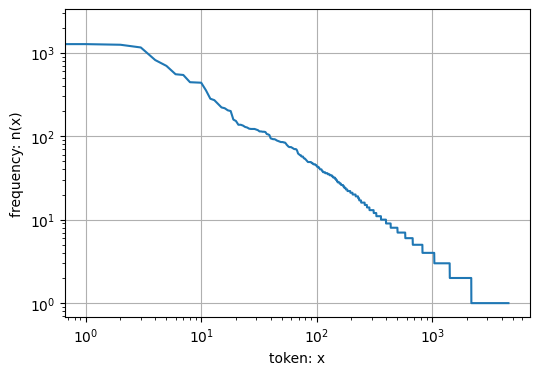

In [4]:
import matplotlib.pyplot as plt

# 提取频率
freqs = [freq for token, freq in vocab.token_freqs]

# 画图
plt.figure(figsize=(6, 4))
plt.plot(freqs)

plt.xlabel('token: x')
plt.ylabel('frequency: n(x)')

# 设置对数坐标
plt.xscale('log')
plt.yscale('log')

plt.grid()
plt.show()

可以看出，词频以一种明确的方式迅速衰减。将前几个单词作为例外消除后，剩余的所有单词大致遵循双对数坐标图上的一条直线。
这意味着单词的频率满足*齐普夫定律*（Zipf's law），
即第$i$个最常用单词的频率$n_i$为：

$$n_i \propto \frac{1}{i^\alpha},$$
:eqlabel:`eq_zipf_law`

等价于

$$\log n_i = -\alpha \log i + c,$$

其中$\alpha$是刻画分布的指数，$c$是常数。

可以看出通过计数统计和平滑来建模单词是不可行的， 因为这样建模的结果会大大高估尾部单词的频率，也就是所谓的不常用单词。

下面看二元语法的频率表现

In [5]:
bigram_tokens = [pair for pair in zip(corpus[:-1], corpus[1:])]
bigram_vocab = Vocab(bigram_tokens)
bigram_vocab.token_freqs[:10]

[(('of', 'the'), 309),
 (('in', 'the'), 169),
 (('i', 'had'), 130),
 (('i', 'was'), 112),
 (('and', 'the'), 109),
 (('the', 'time'), 102),
 (('it', 'was'), 99),
 (('to', 'the'), 85),
 (('as', 'i'), 78),
 (('of', 'a'), 73)]

在十个最频繁的词对中，有九个是由两个停用词组成的， 只有一个与“the time”有关。

下面看三元语法的频率表现

In [6]:
trigram_tokens = [triple for triple in zip(
    corpus[:-2], corpus[1:-1], corpus[2:])]
trigram_vocab = Vocab(trigram_tokens)
trigram_vocab.token_freqs[:10]

[(('the', 'time', 'traveller'), 59),
 (('the', 'time', 'machine'), 30),
 (('the', 'medical', 'man'), 24),
 (('it', 'seemed', 'to'), 16),
 (('it', 'was', 'a'), 15),
 (('here', 'and', 'there'), 15),
 (('seemed', 'to', 'me'), 14),
 (('i', 'did', 'not'), 14),
 (('i', 'saw', 'the'), 13),
 (('i', 'began', 'to'), 13)]

对比三种模型中的词元频率

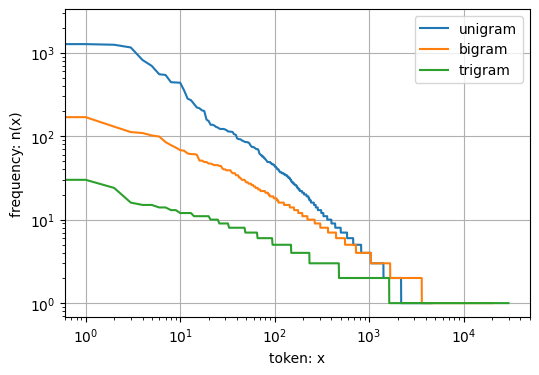

In [9]:
# 频率
bigram_freqs = [freq for token, freq in bigram_vocab.token_freqs]
trigram_freqs = [freq for token, freq in trigram_vocab.token_freqs]

plt.figure(figsize=(6, 4))

# 三条曲线
plt.plot(freqs, label='unigram')
plt.plot(bigram_freqs, label='bigram')
plt.plot(trigram_freqs, label='trigram')

plt.xlabel('token: x')
plt.ylabel('frequency: n(x)')

# 对数坐标
plt.xscale('log')
plt.yscale('log')

plt.legend()
plt.grid()

plt.show()

可以看出，除了一元语法（unigram），二元（bigram）和三元（trigram）词序列同样遵循齐普夫定律，
   即词频分布呈现幂律关系，只是随着 n 的增加，分布曲线的斜率会发生变化。

词表中 n 元组的数量并没有那么大，这说明语言中存在相当多的结构。

很多 n 元组很少出现，这使得拉普拉斯平滑非常不适合语言建模。我们可以使用基于深度学习的模型来代替。


读取长序列数据

在语言模型中，数据通常是一个很长的序列（例如一本书）。
但神经网络无法一次处理整个长序列，因此需要将其拆分成较短的子序列。

将原始长序列划分为固定长度的子序列：
每个子序列长度为 n（时间步数），每个子序列作为一个训练样本

模型输入：
x₁, x₂, …, xₙ  

模型目标（标签）：
x₂, x₃, …, xₙ₊₁  标签是“向右移动一位”的序列



划分时存在一个问题：从哪里开始切分（偏移量）

不同的起始位置会得到不同的子序列。


如果只使用固定偏移，子序列覆盖范围有限，模型可能只学到部分模式。

解决方法：随机偏移

在每次训练时随机选择起始位置，再划分子序列。




随机采样（Random Sampling）

每个子序列都是从原始序列中随机截取的，不同 batch 之间不一定连续

数据形式

batch_size：每个批次的样本数
num_steps：每个样本的时间步长度

输入 X：
(batch_size, num_steps)

标签 Y：
(batch_size, num_steps)



Y 是 X 向右移动一位得到的



将长文本随机切分成多个固定长度的小序列，
用于训练模型预测“下一个词”。

In [10]:
def seq_data_iter_random(corpus, batch_size, num_steps):
    """使用随机抽样生成一个小批量子序列"""
    # 从随机偏移量开始对序列进行分区，随机范围包括num_steps-1
    corpus = corpus[random.randint(0, num_steps - 1):]
    # 减去1，是因为我们需要考虑标签
    num_subseqs = (len(corpus) - 1) // num_steps
    # 长度为num_steps的子序列的起始索引
    initial_indices = list(range(0, num_subseqs * num_steps, num_steps))
    # 在随机抽样的迭代过程中，
    # 来自两个相邻的、随机的、小批量中的子序列不一定在原始序列上相邻
    random.shuffle(initial_indices)

    def data(pos):
        # 返回从pos位置开始的长度为num_steps的序列
        return corpus[pos: pos + num_steps]

    num_batches = num_subseqs // batch_size
    for i in range(0, batch_size * num_batches, batch_size):
        # 在这里，initial_indices包含子序列的随机起始索引
        initial_indices_per_batch = initial_indices[i: i + batch_size]
        X = [data(j) for j in initial_indices_per_batch]
        Y = [data(j + 1) for j in initial_indices_per_batch]
        yield torch.tensor(X), torch.tensor(Y)

下面生成一个从 0 到 34 的序列

In [11]:
my_seq = list(range(35))
for X, Y in seq_data_iter_random(my_seq, batch_size=2, num_steps=5):
    print('X: ', X, '\nY:', Y)

X:  tensor([[17, 18, 19, 20, 21],
        [ 2,  3,  4,  5,  6]]) 
Y: tensor([[18, 19, 20, 21, 22],
        [ 3,  4,  5,  6,  7]])
X:  tensor([[12, 13, 14, 15, 16],
        [27, 28, 29, 30, 31]]) 
Y: tensor([[13, 14, 15, 16, 17],
        [28, 29, 30, 31, 32]])
X:  tensor([[22, 23, 24, 25, 26],
        [ 7,  8,  9, 10, 11]]) 
Y: tensor([[23, 24, 25, 26, 27],
        [ 8,  9, 10, 11, 12]])


顺序分区

迭代过程中，除了对原始序列可以随机抽样外，还可以保证两个相邻的小批量中的子序列在原始序列上也是相邻的。

In [12]:
def seq_data_iter_sequential(corpus, batch_size, num_steps):
    """使用顺序分区生成一个小批量子序列"""
    # 从随机偏移量开始划分序列
    offset = random.randint(0, num_steps)
    num_tokens = ((len(corpus) - offset - 1) // batch_size) * batch_size
    Xs = torch.tensor(corpus[offset: offset + num_tokens])
    Ys = torch.tensor(corpus[offset + 1: offset + 1 + num_tokens])
    Xs, Ys = Xs.reshape(batch_size, -1), Ys.reshape(batch_size, -1)
    num_batches = Xs.shape[1] // num_steps
    for i in range(0, num_steps * num_batches, num_steps):
        X = Xs[:, i: i + num_steps]
        Y = Ys[:, i: i + num_steps]
        yield X, Y

读取每个小批量的子序列的特征X和标签Y，打印出来可以发现： 迭代期间来自两个相邻的小批量中的子序列在原始序列中确实是相邻的

In [13]:
for X, Y in seq_data_iter_sequential(my_seq, batch_size=2, num_steps=5):
    print('X: ', X, '\nY:', Y)

X:  tensor([[ 1,  2,  3,  4,  5],
        [17, 18, 19, 20, 21]]) 
Y: tensor([[ 2,  3,  4,  5,  6],
        [18, 19, 20, 21, 22]])
X:  tensor([[ 6,  7,  8,  9, 10],
        [22, 23, 24, 25, 26]]) 
Y: tensor([[ 7,  8,  9, 10, 11],
        [23, 24, 25, 26, 27]])
X:  tensor([[11, 12, 13, 14, 15],
        [27, 28, 29, 30, 31]]) 
Y: tensor([[12, 13, 14, 15, 16],
        [28, 29, 30, 31, 32]])
